# E-COMMERCE DATA ANALYSIS

## This project analyzes synthetic e-commerce data to identify trends in revenue, customer behavior, and product performance.

Stanisław Kamiński

### Data Generation

Data is generated using Faker and NumPy libraries to simulate realistic customer behavior and purchasing patterns.

In [8]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker('pl_PL')

Generating customers data.

In [9]:
customers = pd.DataFrame({
    'customer_id': range(1,1001),
    'name': [f'{fake.first_name()} {fake.last_name()}' for _ in range(1000)],
    'voivodeship': [fake.region() for _ in range(1000)],
    'age': (np.random.randint(18, 91,size=1000)),
})

Generating products data.

In [10]:
products = pd.DataFrame({
    'product_id': range(1,51),
    'category': np.random.choice(["thriller","fantasy","romance","historical fiction","science fiction"],50),
    'price':np.round(np.random.uniform(low=10,high=150,size=50),2)
})

Generating orders data. Introduction of customer activity variable allows simulation of more diverse customer behavior.

In [11]:
import datetime

customer_activity = np.random.pareto(1.75,1000)+1

orders = []
order_id = 1
for i,activity in enumerate(customer_activity):
    num_orders = max(1, np.random.poisson(activity))
    for _ in range(num_orders):
        order_date = fake.date_between(start_date= datetime.date(2025,1,1), end_date= datetime.date(2026,1,1))
        orders.append([order_id,i+1,order_date])
        order_id += 1

orders = pd.DataFrame(orders, columns=['order_id','customer_id','order_date'])

Generating data regarding the specific items and the number of items in each order. Product weights variable simulates different popularity of each product.

In [12]:
product_weights = np.random.exponential(1.5,size=50)
probs = product_weights/product_weights.sum()

order_items = []
for order in orders["order_id"]:
        num_items = np.random.randint(1,4)
        for _ in range(num_items):
            product_id = np.random.choice(products['product_id'], p=probs)
            quantity = np.random.choice([1,2,3], p=[0.75,0.15,0.1])
            order_items.append([order,product_id, quantity])

order_items = pd.DataFrame(order_items, columns=['order_id','product_id','quantity'])

### Building a database containing all the previously generated data.

In [13]:
import sqlite3

connect = sqlite3.connect("ecommerce.db")
cursor = connect.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.executescript("""DROP TABLE IF EXISTS order_items;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;""")

cursor.executescript("""
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT,
    voivodeship TEXT,
    age INTEGER
);

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    category TEXT,
    price REAL
);
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    order_date DATE,
    FOREIGN KEY(customer_id) REFERENCES customers(customer_id)
);
CREATE TABLE order_items
(
    order_item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER,
    product_id INTEGER,
    quantity   INTEGER,
    FOREIGN KEY(order_id) REFERENCES orders(order_id),
    FOREIGN KEY(product_id) REFERENCES products(product_id)
);
""")

customers.to_sql('customers', con=connect, if_exists='append', index=False)
products.to_sql('products', con=connect, if_exists='append', index=False)
orders.to_sql('orders', con=connect, if_exists='append', index=False)
order_items.to_sql('order_items', con=connect, if_exists='append', index=False)

connect.commit()

### Providing SQL queries to gather information and visualization

Query calculating total revenue generated from all orders.

In [14]:
import matplotlib.pyplot as plt

revenue = connect.execute("""
SELECT SUM(p.price*oi.quantity) AS total_revenue
FROM order_items AS oi
JOIN products AS p ON oi.product_id = p.product_id;
""").fetchone()
print(revenue[0])

(587677.82,)


Total revenue number indicates the overall scale of the simulated business.

Query calculating total revenue generated each month.

In [15]:
monthly_revenue = pd.read_sql("""
SELECT strftime('%Y-%m', o.order_date) as month, SUM (p.price*oi.quantity) as revenue
FROM orders AS o
JOIN order_items AS oi ON o.order_id = oi.order_id
JOIN products AS p ON oi.product_id = p.product_id
GROUP BY month
ORDER BY month;
""", connect)

Visualization of the monthly revenue data using a line chart.

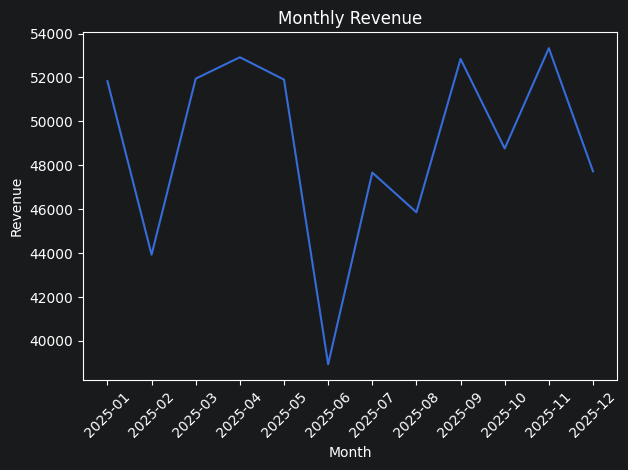

In [16]:
plt.figure()
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'])
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue.png")
plt.show()

Total revenue for each months allows seasonality analysis.

Query calculating the 10 clients generating most income.

In [17]:
top_customers = pd.read_sql("""
SELECT c.customer_id, c.name, SUM(p.price*oi.quantity) as revenue
FROM customers AS c
JOIN orders AS o ON c.customer_id = o.customer_id
JOIN order_items AS oi ON o.order_id = oi.order_id
JOIN products AS p ON oi.product_id = p.product_id
GROUP BY c.customer_id, c.name
ORDER BY revenue DESC
LIMIT 10;
""",connect)

Visualization of the top customers data using a bar chart.

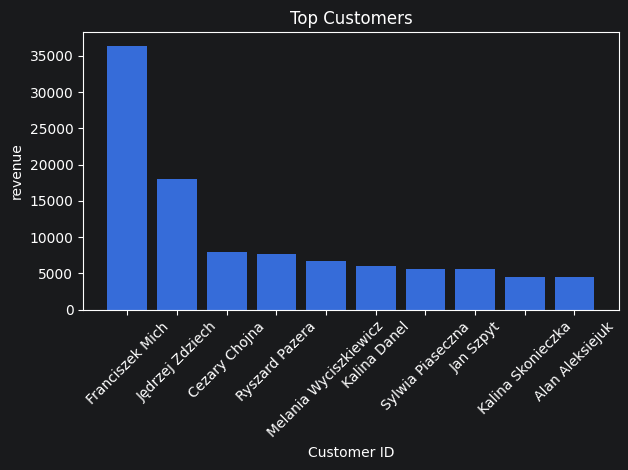

In [18]:
plt.figure()
plt.bar(top_customers['name'], top_customers['revenue'])
plt.title("Top Customers")
plt.xlabel("Customer ID")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_customers.png")
plt.show()

Few top customers correspond to the majority of the income, confirming the Pareto principle.

Query calculating the average value of a single order.

In [19]:
average_revenue = connect.execute("""
SELECT AVG (order_total)
FROM (SELECT o.order_id, SUM(p.price * oi.quantity) as order_total
    FROM orders o
    JOIN order_items AS oi ON o.order_id = oi.order_id
    JOIN products AS p ON oi.product_id = p.product_id
    GROUP BY o.order_id
    )
""").fetchone()
print(average_revenue[0])

(208.91497333807322,)


Average order value provides insights into customer habits.

Query sorting products by category in an order by revenue.

In [20]:
top_categories = pd.read_sql("""
SELECT p.category, SUM(p.price*oi.quantity) as revenue
FROM products AS p
JOIN order_items AS oi ON p.product_id = oi.product_id
GROUP BY p.category
ORDER BY revenue DESC
""",connect)

Visualization of the top categories data using a bar chart.

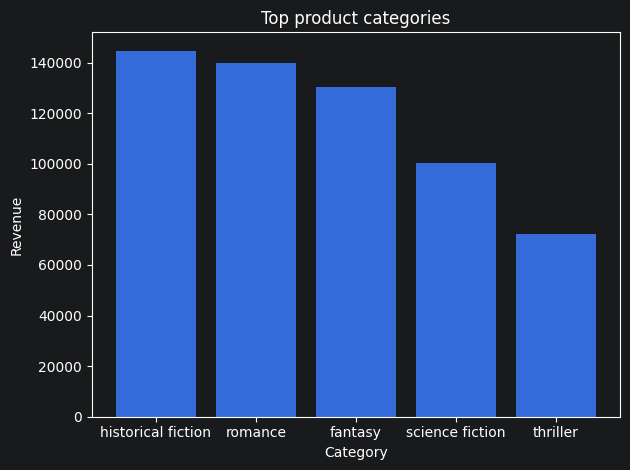

In [21]:
plt.figure()
plt.bar(top_categories['category'], top_categories['revenue'])
plt.title("Top product categories")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("top_categories.png")
plt.show()

The top categories data indicates the demand for specific type of products.

Query calculating the 10 most sold products.

In [22]:
top_products = pd.read_sql("""
SELECT p.product_id, SUM(p.price*oi.quantity) as revenue
FROM products AS p
JOIN order_items AS oi ON p.product_id = oi.product_id
GROUP BY p.product_id
ORDER BY revenue DESC
LIMIT 10;
""",connect)

Vizualization of the top products data using a bar chart.

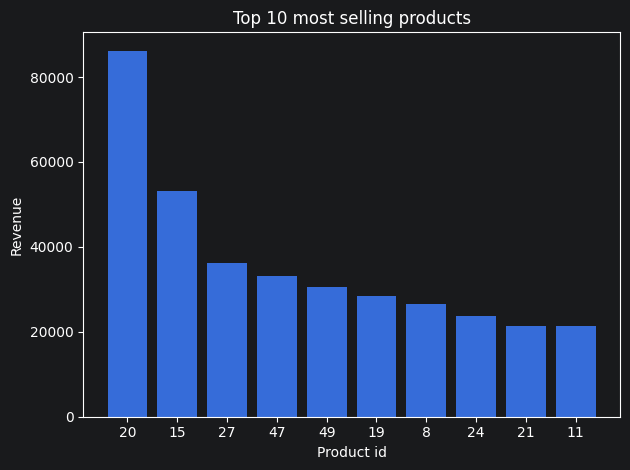

In [23]:
plt.figure()
plt.bar(top_products['product_id'].astype(str), top_products['revenue'])
plt.title("Top 10 most selling products")
plt.xlabel("Product id")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

Top products indicate the key drivers of sales.

This analysis highlights key patterns in customer behavior and product performance. It could support decision-making in areas such as marketing strategy, product optimization, and customer retention. Future work could include customer segmentation based on geographic regions (voivodeships data already exists in the database) as well as cohort analysis